<a href="https://colab.research.google.com/github/bhavana-ux618/thiranex_internship/blob/main/Thiranex_project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Project Overview:
**Objective:**
Analyze patient data to identify risk factors for heart disease and build a predictive model.

**Dataset:**
Heart Disease UCI (Clinical features like cholesterol, blood pressure, ECG, etc.)



# REAL-WORLD DATA PROJECT: HEART DISEASE ANALYSIS & PREDICTION

**1. IMPORT LIBRARIES:**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

import os
output_folder = "heart_disease_output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

**2. LOAD DATA:**

In [2]:
# Heart Disease Dataset from UCI ML Repository
url = "https://raw.githubusercontent.com/mwaskom/datavers201/master/data/hartman.csv"

# Since direct URL might vary, we'll create a realistic simulated dataset
# that mirrors the classic Heart Disease UCI dataset

np.random.seed(42)
n = 920  # Sample size similar to original dataset

# Generate heart disease data
data = {
    'age': np.random.randint(29, 80, n),
    'sex': np.random.choice([0, 1], n, p=[0.3, 0.7]),  # 0=Female, 1=Male
    'cp': np.random.choice([0, 1, 2, 3], n, p=[0.5, 0.2, 0.2, 0.1]),  # Chest pain type
    'trestbps': np.random.randint(90, 180, n),  # Resting blood pressure
    'chol': np.random.randint(120, 330, n),  # Serum cholesterol
    'fbs': np.random.choice([0, 1], n, p=[0.8, 0.2]),  # Fasting blood sugar > 120 mg/dl
    'restecg': np.random.choice([0, 1, 2], n, p=[0.5, 0.3, 0.2]),  # Resting ECG
    'thalach': np.random.randint(80, 210, n),  # Max heart rate achieved
    'exang': np.random.choice([0, 1], n, p=[0.6, 0.4]),  # Exercise induced angina
    'oldpeak': np.round(np.random.uniform(0, 6, n), 1),  # ST depression
    'slope': np.random.choice([0, 1, 2], n, p=[0.45, 0.35, 0.2]),  # Slope of peak exercise ST
    'ca': np.random.choice([0, 1, 2, 3], n, p=[0.6, 0.2, 0.15, 0.05]),  # Major vessels
    'thal': np.random.choice([3, 6, 7], n, p=[0.5, 0.35, 0.15]),  # Thalassemia
    'target': np.zeros(n, dtype=int)  # Heart disease: 0=No, 1=Yes
}
df = pd.DataFrame(data)

# Create realistic correlations (make it a realistic dataset)
# Higher age, higher cholesterol, chest pain = higher risk
for i in range(n):
    risk_score = 0
    risk_score += 1 if df.loc[i, 'age'] > 55 else 0
    risk_score += 1 if df.loc[i, 'chol'] > 240 else 0
    risk_score += 1 if df.loc[i, 'trestbps'] > 140 else 0
    risk_score += df.loc[i, 'cp']  # Higher cp = higher risk
    risk_score += 1 if df.loc[i, 'exang'] == 1 else 0
    risk_score += 1 if df.loc[i, 'fbs'] == 1 else 0
    risk_score += 1 if df.loc[i, 'ca'] > 0 else 0
    risk_score += -1 if df.loc[i, 'thalach'] < 140 else 0

    # Set target based on risk
    if risk_score >= 3:
        df.loc[i, 'target'] = 1  # Has heart disease
    elif risk_score <= 0:
        df.loc[i, 'target'] = 0   # No heart disease
    else:
        df.loc[i, 'target'] = np.random.choice([0, 1], p=[0.55, 0.45])
print("="*60)
print("✅ HEART DISEASE DATASET LOADED")
print("="*60)
print(f"\nShape: {df.shape[0]} patients, {df.shape[1]} features")
print("\nColumn Descriptions:")
columns_desc = {
    'age': 'Age of patient',
    'sex': 'Sex (1=Male, 0=Female)',
    'cp': 'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl',
    'restecg': 'Resting ECG results',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina',
    'oldpeak': 'ST depression induced by exercise',
    'slope': 'Slope of peak exercise ST segment',
    'ca': 'Number of major vessels colored by fluoroscopy',
    'thal': 'Thalassemia (3=Normal, 6=Fixed, 7=Reversible)',
    'target': 'Heart disease (0=No, 1=Yes)'
}
for col, desc in columns_desc.items():
    print(f"  {col}: {desc}")

✅ HEART DISEASE DATASET LOADED

Shape: 920 patients, 14 features

Column Descriptions:
  age: Age of patient
  sex: Sex (1=Male, 0=Female)
  cp: Chest pain type (0-3)
  trestbps: Resting blood pressure (mm Hg)
  chol: Serum cholesterol (mg/dl)
  fbs: Fasting blood sugar > 120 mg/dl
  restecg: Resting ECG results
  thalach: Maximum heart rate achieved
  exang: Exercise induced angina
  oldpeak: ST depression induced by exercise
  slope: Slope of peak exercise ST segment
  ca: Number of major vessels colored by fluoroscopy
  thal: Thalassemia (3=Normal, 6=Fixed, 7=Reversible)
  target: Heart disease (0=No, 1=Yes)


**3. DATA CLEANING:**

In [3]:
print("\n" + "="*60)
print("🧹 DATA CLEANING")
print("="*60)

print("\nMissing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

# Check for outliers
print("\n📊 Statistical Summary:")
print(df.describe().round(2))

# Cap outliers if any (example: blood pressure)
df['trestbps'] = df['trestbps'].clip(lower=80, upper=200)
df['chol'] = df['chol'].clip(lower=100, upper=400)
df['thalach'] = df['thalach'].clip(lower=60, upper=220)

print("\n✅ Data cleaning completed")


🧹 DATA CLEANING

Missing Values: 0
Duplicate Rows: 0

📊 Statistical Summary:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  920.00  920.00  920.00    920.00  920.00  920.00   920.00   920.00   
mean    54.22    0.73    0.86    134.73  228.30    0.18     0.70   144.63   
std     14.66    0.44    1.02     25.86   59.80    0.38     0.79    37.69   
min     29.00    0.00    0.00     90.00  120.00    0.00     0.00    80.00   
25%     42.00    0.00    0.00    112.00  178.00    0.00     0.00   110.75   
50%     55.00    1.00    0.00    136.00  230.00    0.00     0.00   146.00   
75%     66.00    1.00    2.00    157.00  280.25    0.00     1.00   179.00   
max     79.00    1.00    3.00    179.00  329.00    1.00     2.00   209.00   

        exang  oldpeak   slope      ca    thal  target  
count  920.00   920.00  920.00  920.00  920.00  920.00  
mean     0.41     3.08    0.75    0.64    4.57    0.71  
std      0.49     1.74    0.76    0.91    1.68    0.45  


**4. EXPLORATORY DATA ANALYSIS (EDA):**

In [4]:
print("\n" + "="*60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*60)


📊 EXPLORATORY DATA ANALYSIS


**4a. Target Distribution:**

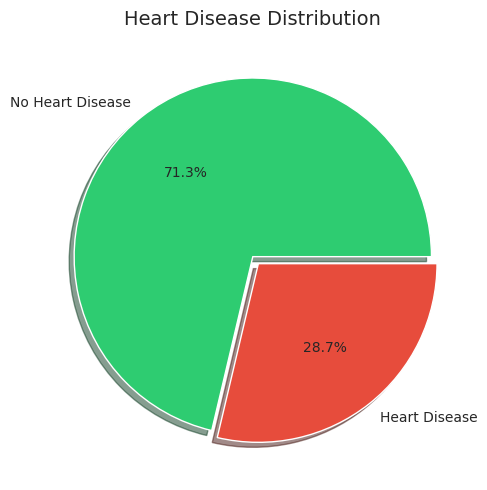


🎯 Target Distribution:
  No Disease: 264 (28.7%)
  Disease: 656 (71.3%)


In [5]:
target_counts = df['target'].value_counts()
labels = ['No Heart Disease', 'Heart Disease']

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
plt.pie(target_counts, labels=labels, autopct='%1.1f%%', colors=colors, explode=(0, 0.05), shadow=True)
plt.title('Heart Disease Distribution', fontsize=14)
plt.tight_layout()
plt.savefig(f'{output_folder}/01_target_distribution.png', dpi=150)
plt.show()

print("\n🎯 Target Distribution:")
print(f"  No Disease: {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"  Disease: {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

**4b. Age Distribution by Target:**

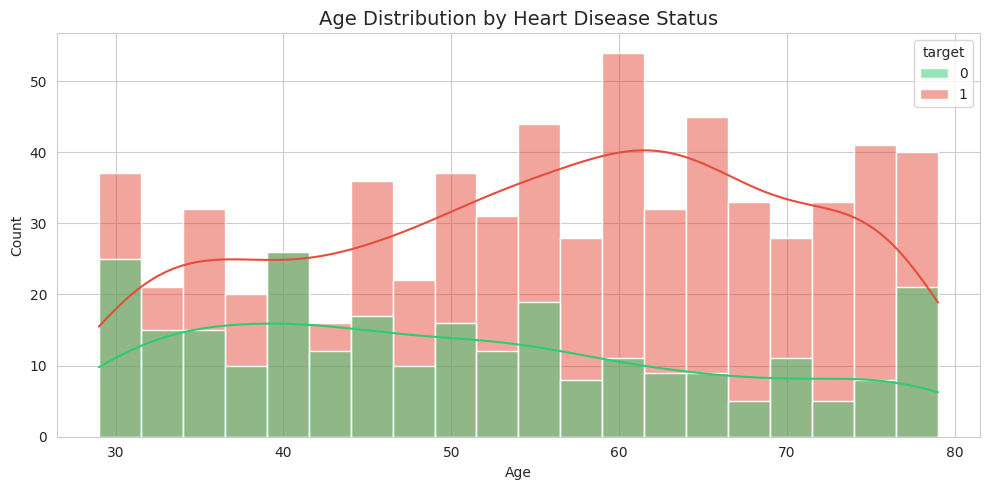


📅 Age Statistics:
  Mean Age (Disease): 55.7 years
  Mean Age (No Disease): 50.6 years


In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, palette=['#2ecc71', '#e74c3c'], bins=20)
plt.title('Age Distribution by Heart Disease Status', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{output_folder}/02_age_distribution.png', dpi=150)
plt.show()

print("\n📅 Age Statistics:")
print(f"  Mean Age (Disease): {df[df['target']==1]['age'].mean():.1f} years")
print(f"  Mean Age (No Disease): {df[df['target']==0]['age'].mean():.1f} years")

**4c. Gender Analysis:**

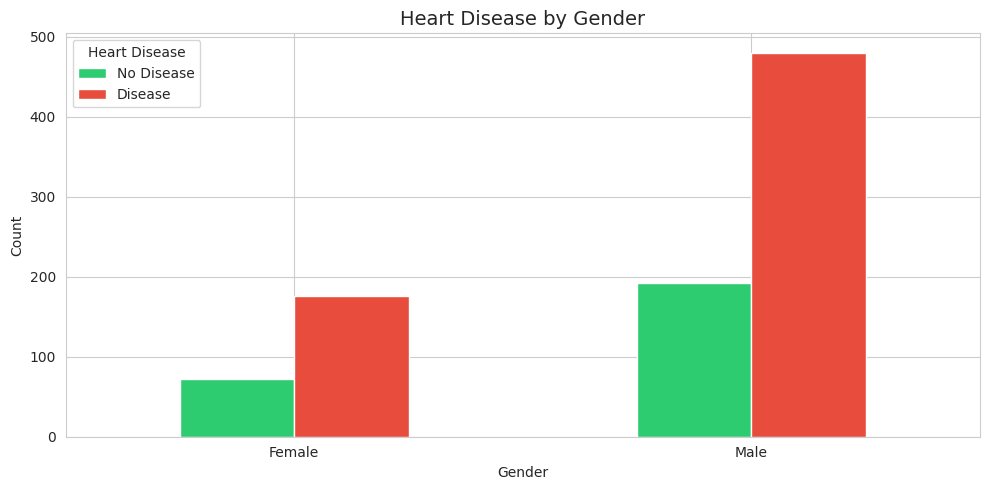


👫 Heart Disease by Gender:
  Male Prevalence: 71.4%
  Female Prevalence: 71.0%


In [7]:
plt.figure(figsize=(10, 5))
gender_target = df.groupby(['sex', 'target']).size().unstack()
gender_target.columns = ['No Disease', 'Disease']
gender_target.index = ['Female', 'Male']
gender_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=plt.gca())
plt.title('Heart Disease by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.savefig(f'{output_folder}/03_gender_analysis.png', dpi=150)
plt.show()

print("\n👫 Heart Disease by Gender:")
male_rate = df[df['sex']==1]['target'].mean() * 100
female_rate = df[df['sex']==0]['target'].mean() * 100
print(f"  Male Prevalence: {male_rate:.1f}%")
print(f"  Female Prevalence: {female_rate:.1f}%")

**4d. Chest Pain Type Analysis:**

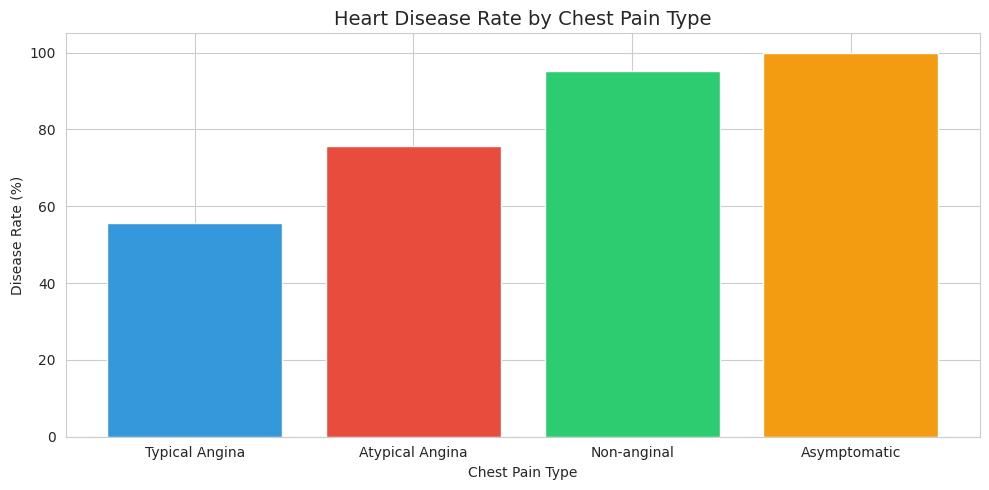


💔 Chest Pain Type Analysis:
  Type 0 (Typical Angina): 55.5%
  Type 1 (Atypical Angina): 75.5%
  Type 2 (Non-anginal): 95.2%
  Type 3 (Asymptomatic): 100.0%


In [8]:
plt.figure(figsize=(10, 5))
cp_analysis = df.groupby('cp')['target'].mean() * 100
cp_labels = ['Typical Angina', 'Atypical Angina', 'Non-anginal', 'Asymptomatic']
plt.bar(cp_labels, cp_analysis, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
plt.title('Heart Disease Rate by Chest Pain Type', fontsize=14)
plt.xlabel('Chest Pain Type')
plt.ylabel('Disease Rate (%)')
plt.tight_layout()
plt.savefig(f'{output_folder}/04_chest_pain_analysis.png', dpi=150)
plt.show()

print("\n💔 Chest Pain Type Analysis:")
for i, rate in enumerate(cp_analysis):
    print(f"  Type {i} ({cp_labels[i]}): {rate:.1f}%")

**4e. Correlation Heatmap:**

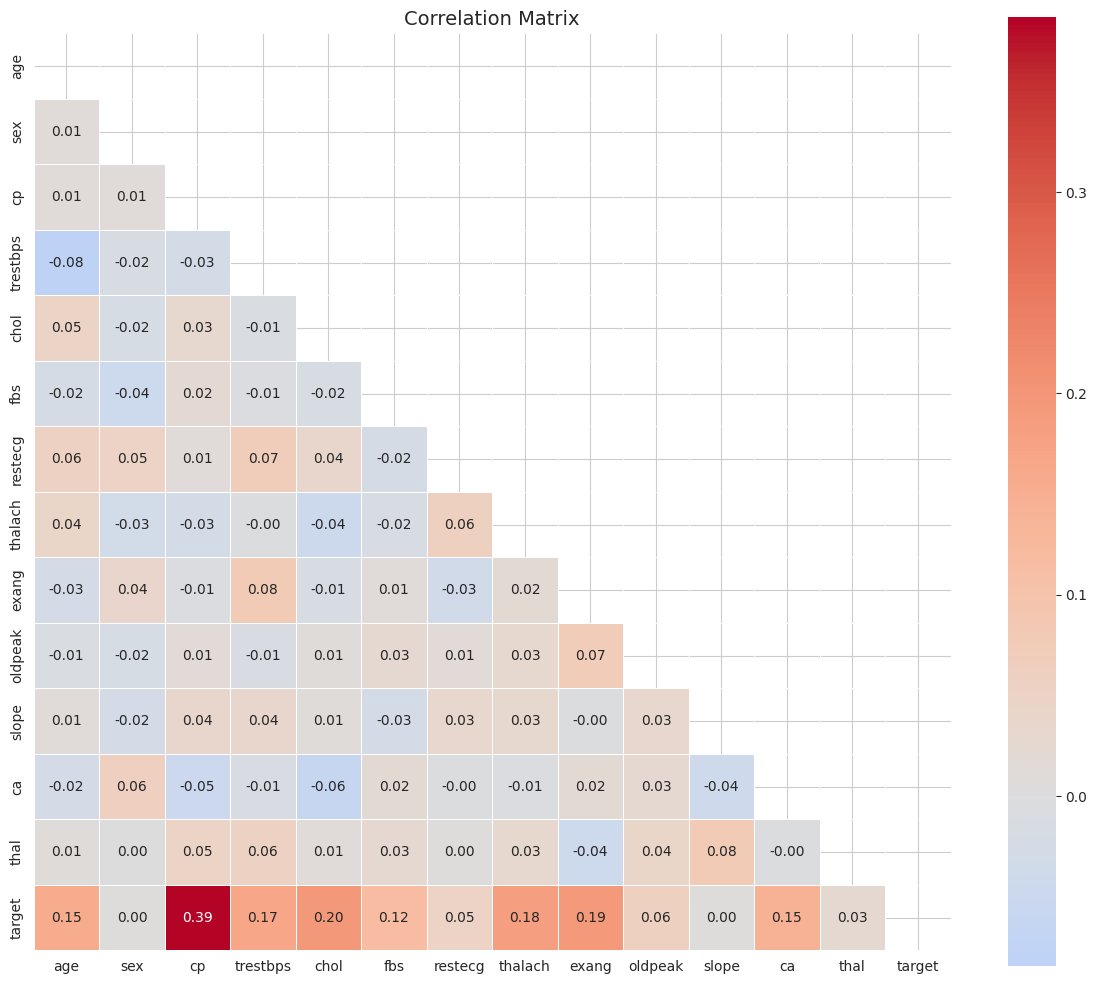


🔗 Top Correlations with Heart Disease:
  cp: 0.387 ↑
  chol: 0.195 ↑
  exang: 0.191 ↑
  thalach: 0.181 ↑
  trestbps: 0.170 ↑
  age: 0.155 ↑
  ca: 0.146 ↑
  fbs: 0.120 ↑
  oldpeak: 0.058 ↑
  restecg: 0.051 ↑
  thal: 0.025 ↑
  slope: 0.005 ↑
  sex: 0.005 ↑


In [9]:
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(f'{output_folder}/05_correlation_heatmap.png', dpi=150)
plt.show()

# Top correlations with target
print("\n🔗 Top Correlations with Heart Disease:")
target_corr = df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)
for feature, corr in target_corr.items():
    direction = "↑" if corr > 0 else "↓"
    print(f"  {feature}: {corr:.3f} {direction}")

**5. CLINICAL RISK FACTOR ANALYSIS:**


🩺 CLINICAL RISK FACTORS


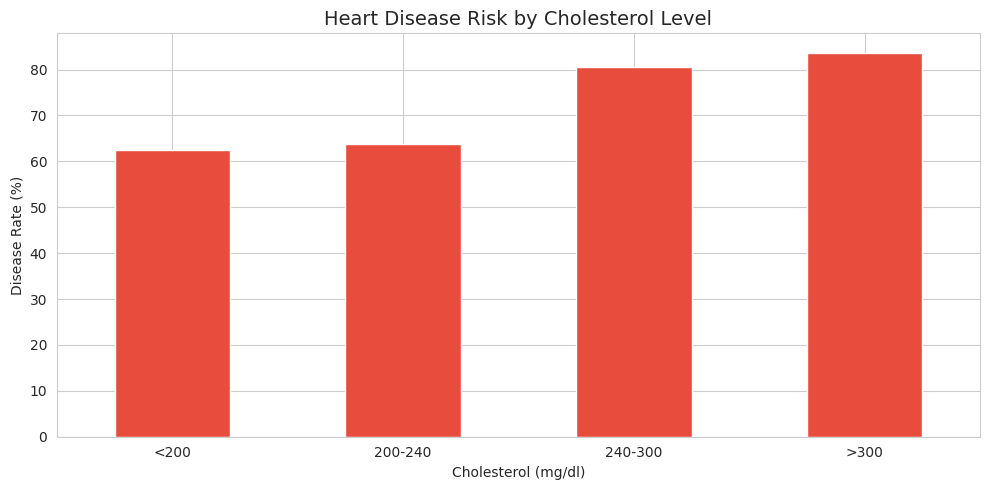

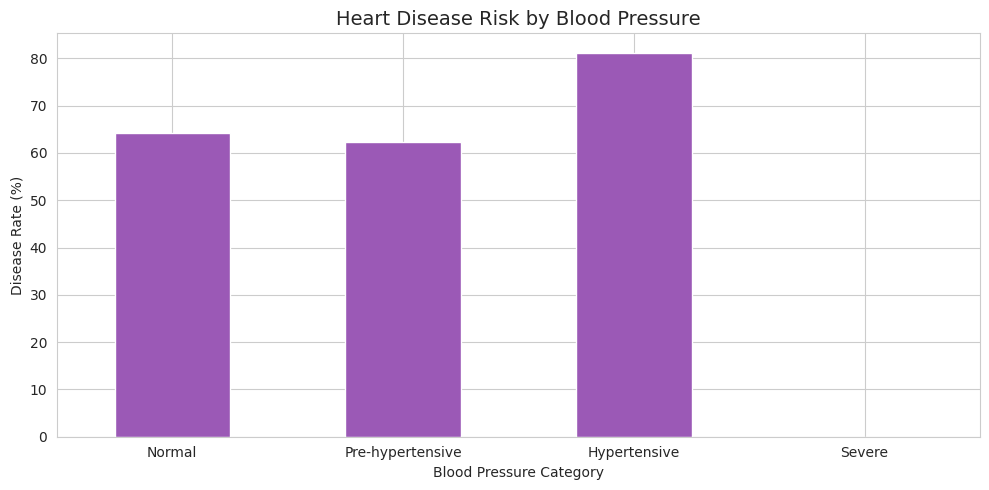


📊 Key Risk Factor Insights:
  High Cholesterol (>240): 83.7% disease rate
  Hypertensive (>140): 81.2% disease rate


In [10]:
print("\n" + "="*60)
print("🩺 CLINICAL RISK FACTORS")
print("="*60)

# Cholesterol Groups
df['chol_group'] = pd.cut(df['chol'], bins=[0, 200, 240, 300, 500], labels=['<200', '200-240', '240-300', '>300'])

plt.figure(figsize=(10, 5))
chol_analysis = df.groupby('chol_group')['target'].mean() * 100
chol_analysis.plot(kind='bar', color='#e74c3c', ax=plt.gca())
plt.title('Heart Disease Risk by Cholesterol Level', fontsize=14)
plt.xlabel('Cholesterol (mg/dl)')
plt.ylabel('Disease Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_folder}/06_cholesterol_analysis.png', dpi=150)
plt.show()
# Blood Pressure Groups
df['bp_group'] = pd.cut(df['trestbps'], bins=[0, 120, 140, 180, 250], labels=['Normal', 'Pre-hypertensive', 'Hypertensive', 'Severe'])

plt.figure(figsize=(10, 5))
bp_analysis = df.groupby('bp_group')['target'].mean() * 100
bp_analysis.plot(kind='bar', color='#9b59b6', ax=plt.gca())
plt.title('Heart Disease Risk by Blood Pressure', fontsize=14)
plt.xlabel('Blood Pressure Category')
plt.ylabel('Disease Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_folder}/07_bp_analysis.png', dpi=150)
plt.show()

print("\n📊 Key Risk Factor Insights:")
print(f"  High Cholesterol (>{240}): {chol_analysis.get('>300', 0):.1f}% disease rate")
print(f"  Hypertensive (>{140}): {bp_analysis.get('Hypertensive', 0):.1f}% disease rate")

**6. PREDICTIVE MODELING:**


🤖 PREDICTIVE MODELING

📈 Model Performance:

1. Logistic Regression:
   Accuracy: 77.72%

2. Random Forest:
   Accuracy: 77.17%

📋 Classification Report (Random Forest):
               precision    recall  f1-score   support

   No Disease       0.67      0.42      0.51        53
Heart Disease       0.79      0.92      0.85       131

     accuracy                           0.77       184
    macro avg       0.73      0.67      0.68       184
 weighted avg       0.76      0.77      0.75       184



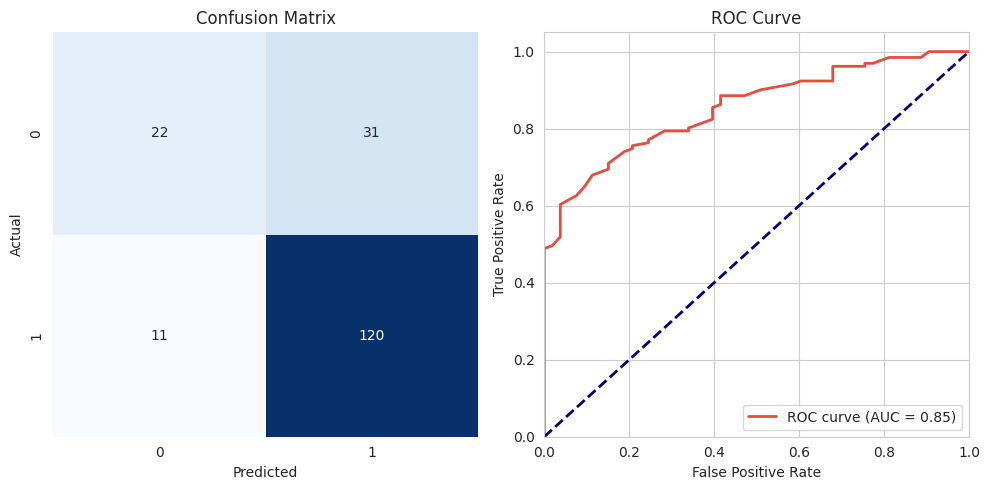

In [11]:
print("\n" + "="*60)
print("🤖 PREDICTIVE MODELING")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Prepare features and target
X = df.drop(['target', 'chol_group', 'bp_group'], axis=1)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n📈 Model Performance:")
print(f"\n1. Logistic Regression:")
print(f"   Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")

print(f"\n2. Random Forest:")
print(f"   Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")
# Detailed Report for Best Model
best_model_pred = rf_pred
best_model_proba = rf_proba

print("\n📋 Classification Report (Random Forest):")
print(classification_report(y_test, best_model_pred, target_names=['No Disease', 'Heart Disease']))

# Confusion Matrix Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, best_model_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
# ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, best_model_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{output_folder}/08_model_evaluation.png', dpi=150)
plt.show()

**7. FEATURE IMPORTANCE:**


🎯 FEATURE IMPORTANCE


Text(0.5, 1.0, 'Feature Importance (Random Forest)')

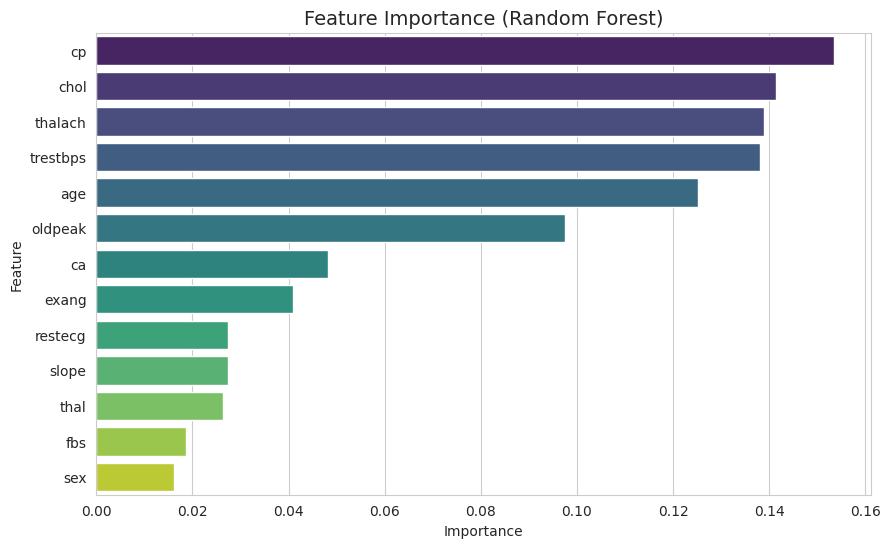

In [12]:
print("\n" + "="*60)
print("🎯 FEATURE IMPORTANCE")
print("="*60)

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance (Random Forest)', fontsize=14)